# Advanced Statistical Visualisations with Statistical API

In this notebook you will learn how to create more advanced visualisations using the outputs from the Processing and Statistical APIs. If you are new to the Statistical API, and have not yet viewed the [notebook](sentinelhub/Statistical_API_basic_timeseries_visualisations.ipynb) covering basic time series, we recommend you start there. 

### Python Library Imports

In [1]:
# Utilities
import os
import getpass
import warnings

# Data Manipulation
import pandas as pd
import geopandas as gpd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import contextily as cx

# Geospatial and Interpolation
from scipy.interpolate import interp1d
import rasterio

# Sentinel Hub
from sentinelhub import (
    SHConfig,
    DataCollection,
    SentinelHubRequest,
    SentinelHubDownloadClient,
    SentinelHubStatistical,
    SentinelHubStatisticalDownloadClient,
    BBox,
    CRS,
    MimeType,
    Geometry,
    parse_time,
)

warnings.filterwarnings("ignore", category=UserWarning)  # Suppress specific warnings

### Helper Functions

In [2]:
# Helper Utility Functions


# define function to transform Statistical API response into a pandas.DataFrame


def stats_to_df(stats_data):
    """Transform Statistical API response into a pandas.DataFrame"""
    df_data = []

    for single_data in stats_data["data"]:
        df_entry = {}
        is_valid_entry = True

        df_entry["interval_from"] = parse_time(single_data["interval"]["from"]).date()
        df_entry["interval_to"] = parse_time(single_data["interval"]["to"]).date()

        for output_name, output_data in single_data["outputs"].items():
            for band_name, band_values in output_data["bands"].items():
                band_stats = band_values["stats"]
                if band_stats["sampleCount"] == band_stats["noDataCount"]:
                    is_valid_entry = False
                    break

                for stat_name, value in band_stats.items():
                    col_name = f"{output_name}_{band_name}_{stat_name}"
                    if stat_name == "percentiles":
                        for perc, perc_val in value.items():
                            perc_col_name = f"{col_name}_{perc}"
                            df_entry[perc_col_name] = perc_val
                    else:
                        df_entry[col_name] = value

        if is_valid_entry:
            df_data.append(df_entry)

    return pd.DataFrame(df_data)

## Credentials

Credentials for Sentinel Hub services (`client_id` & `client_secret`) can be obtained in your [Dashboard](https://shapps.dataspace.copernicus.eu/dashboard/#/). In the User Settings you can create a new OAuth Client to generate these credentials. For more detailed instructions, visit the relevant [documentation page](https://documentation.dataspace.copernicus.eu/APIs/SentinelHub/Overview/Authentication.html).

Now that you have your `client_id` & `client_secret`, it is recommended to configure a new profile in your Sentinel Hub Python package. Instructions on how to configure your Sentinel Hub Python package can be found [here](https://sentinelhub-py.readthedocs.io/en/latest/configure.html). Using these instructions you can create a profile specific to using the package for accessing Copernicus Data Space Ecosystem data collections. This is useful as changes to the the config class are usually only temporary in your notebook and by saving the configuration to your profile you won't need to generate new credentials or overwrite/change the default profile each time you rerun or write a new Jupyter Notebook. 

If you are a first time user of the Sentinel Hub Python package for Copernicus Data Space Ecosystem, you should create a profile specific to the Copernicus Data Space Ecosystem. You can do this in the following cell:

In [3]:
# Only run this cell if you have not created a configuration.

config = SHConfig()
##config.sh_client_id = getpass.getpass("Enter your SentinelHub client id")
# config.sh_client_secret = getpass.getpass("Enter your SentinelHub client secret")
config.sh_token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
config.sh_base_url = "https://sh.dataspace.copernicus.eu"
# config.save("cdse")

However, if you have already configured a profile in Sentinel Hub Python for the Copernicus Data Space Ecosystem, then you can run the below cell entering the profile name as a string replacing `<profile_name>`.

In [4]:
config = SHConfig("cdse")

## 1. How to plot a spectral signature plot for a field of interest

As well as creating time series with Statistical API, we can also derive more simple analyses like a spectral signature plot using the API output. This can be useful if you want to compare the spectral response of different land cover types. For this example, let's compare the spectral signature of four polygons; one will be urban, the second forest, the third grassland, and fourth terrestrial water. Firstly, let's build the evalscript.

### Creating a field of interest

For this example we have created some fields of interests for the different land cover types in and around Geneva, Switzerland. We will use Sentinel-2 L2A to create the spectral signature plot.

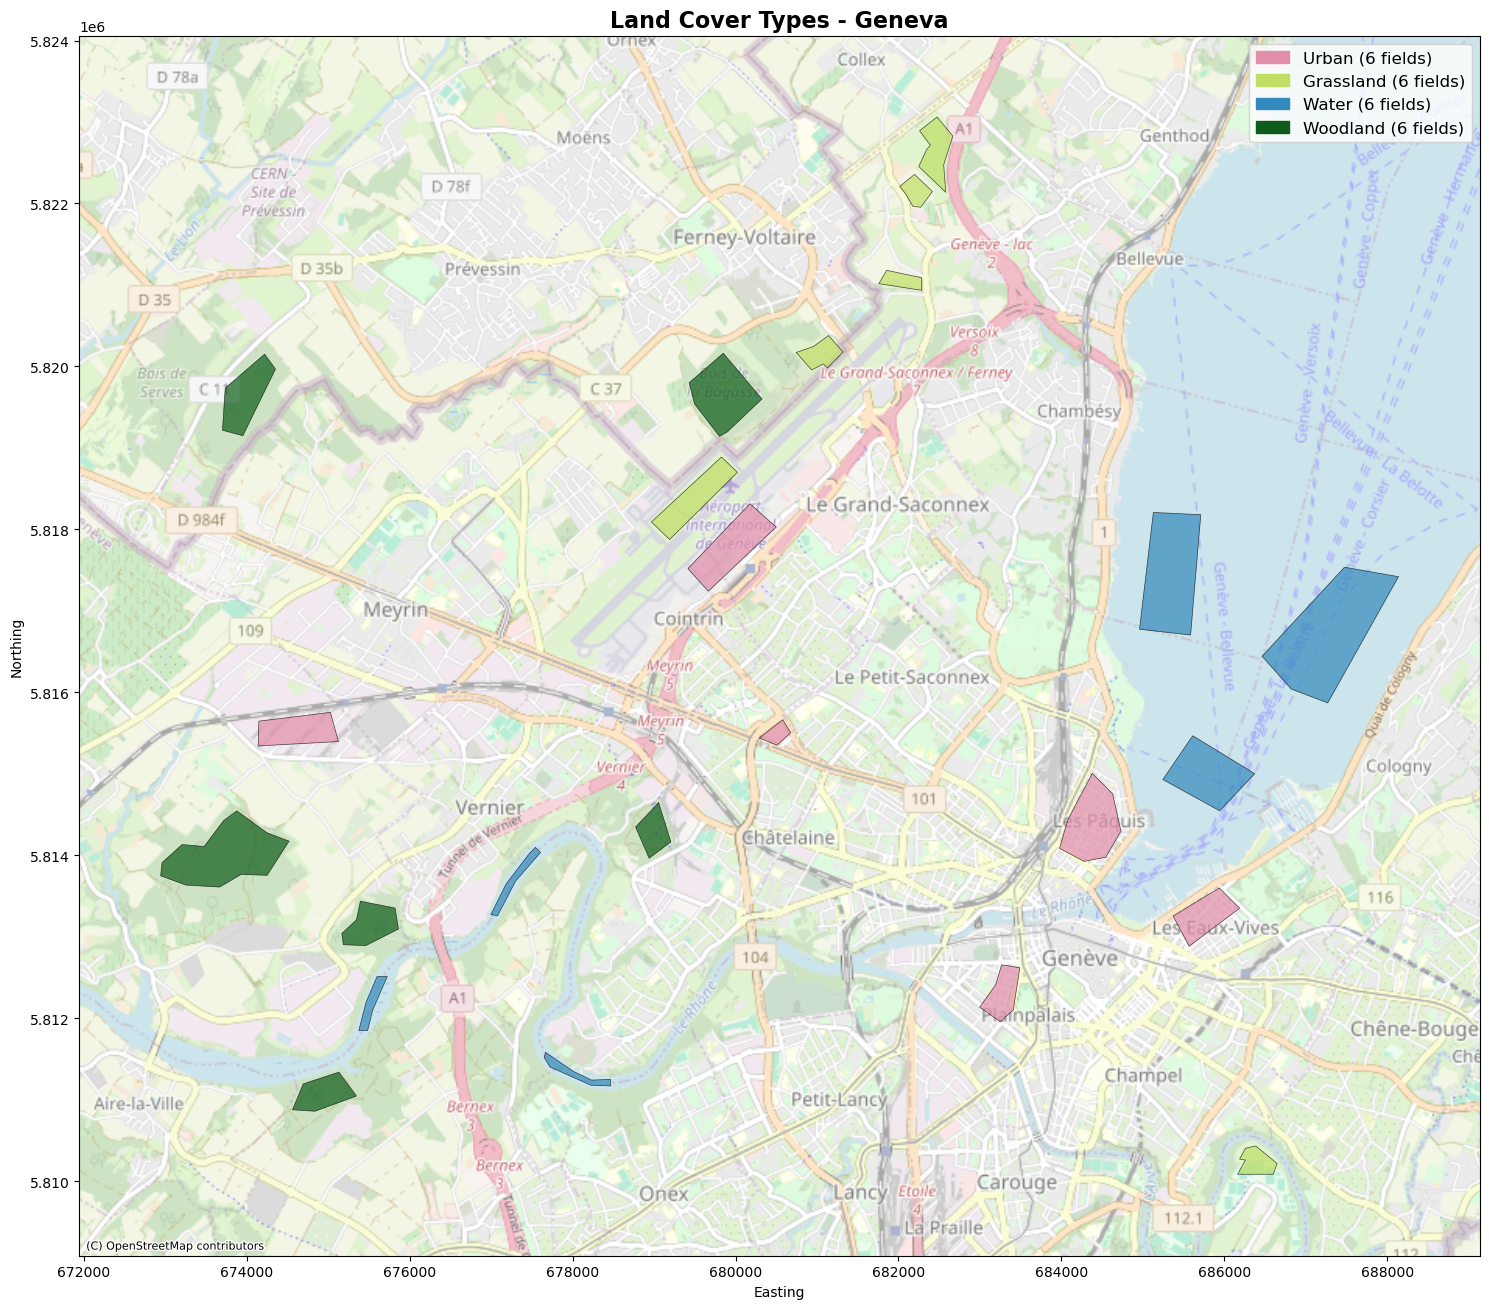

In [5]:
# Load the Geneva landcover data
landcover_samples = gpd.read_file("../../data/geneva_landcover.geojson")

# Convert fields to Web Mercator for proper basemap alignment
landcover_samples_wm = landcover_samples.to_crs(epsg=3857)

# Create a figure to visualize the land cover types
fig, ax = plt.subplots(figsize=(15, 15))

# Define colors for each land cover type (CORINE-inspired palette)
landcover_colors = {
    "Urban": "#e28da9",  # CORINE artificial surfaces (magenta-red)
    "Grassland": "#c0de64",  # CORINE pastures / natural grassland
    "Water": "#338abd",  # CORINE water bodies
    "Woodland": "#0d5c1a",  # CORINE broad-leaved / mixed forest
}

# Plot each land cover type with different colors
legend_handles = []
for lc_type, color in landcover_colors.items():
    lc_fields = landcover_samples_wm[landcover_samples_wm["landcover"] == lc_type]
    if len(lc_fields) > 0:
        lc_fields.plot(ax=ax, color=color, alpha=0.7, edgecolor="black", linewidth=0.5)
        patch = mpatches.Patch(
            color=color, label=f"{lc_type} ({len(lc_fields)} fields)"
        )
        legend_handles.append(patch)

# Set the axis limits to the bounds of the fields (with valid bounds now)
bounds = landcover_samples_wm.total_bounds
if np.isfinite(bounds).all():
    buffer = 1000  # 1km buffer around fields
    ax.set_xlim(bounds[0] - buffer, bounds[2] + buffer)
    ax.set_ylim(bounds[1] - buffer, bounds[3] + buffer)

# Add basemap for context
try:
    cx.add_basemap(
        ax,
        crs=landcover_samples_wm.crs,
        source=cx.providers.OpenStreetMap.Mapnik,
        alpha=0.6,
    )
except Exception as e:
    print(f"Could not add basemap: {e}")

# Add legend manually
if legend_handles:
    ax.legend(handles=legend_handles, loc="upper right", fontsize=12)

# Set title and labels
ax.set_title("Land Cover Types - Geneva", fontsize=16, fontweight="bold")
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")

plt.tight_layout()
plt.show()

### The Evalscript

In this evalscript we will extract out statistics for every band from the Sentinel-2 L2A data collection. Each of these must be defined as a seperate output. This makes a long evalscript but actually there is just a lot of repetition here so nothing to worry about.

In [6]:
evalscript = """
//VERSION=3
  function setup() {
    return {
      input: [
        {
          bands: ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B09", "B11", "B12", "dataMask"],
        },
      ],
      output: [
      {
        id: "B01",
        bands: 1
      },
      {
        id: "B02",
        bands: 1
      },
      {
        id: "B03",
        bands: 1
      },
      {
        id: "B04",
        bands: 1
      },
      {
        id: "B05",
        bands: 1
      },
      {
        id: "B06",
        bands: 1
      },
      {
        id: "B07",
        bands: 1
      },
      {
        id: "B08",
        bands: 1
      },
      {
        id: "B8A",
        bands: 1
      },
      {
        id: "B09",
        bands: 1
      },
      {
        id: "B11",
        bands: 1
      },
      {
        id: "B12",
        bands: 1
      },
      {
        id: "dataMask",
        bands: 1
      }
    ]
  }
}
  
function evaluatePixel(samples) {

    return {
      B01: [10 * samples.B01],
      B02: [10 * samples.B02],
      B03: [10 * samples.B03],
      B04: [10 * samples.B04],
      B05: [10 * samples.B05],
      B06: [10 * samples.B06],
      B07: [10 * samples.B07],
      B08: [10 * samples.B08],      
      B8A: [10 * samples.B8A],
      B09: [10 * samples.B09],
      B11: [10 * samples.B11],
      B12: [10 * samples.B12],      
      dataMask: [samples.dataMask]
    };
    }
"""

### The Request Body

In [7]:
# Dissolve polygons by landcover type to get one geometry per type
lcs_gdf = landcover_samples.dissolve(by="landcover").reset_index()

aggregation = SentinelHubStatistical.aggregation(
    evalscript=evalscript,
    time_interval=("2025-05-30", "2025-05-31"),
    aggregation_interval="P1D",
    resolution=(0.0001, 0.0001),
)

input_data = SentinelHubStatistical.input_data(
    DataCollection.SENTINEL2_L2A.define_from("s2l2a", service_url=config.sh_base_url),
    maxcc=0.3,
)

lcs_requests = []

for geo_shape in lcs_gdf.geometry.values:
    request = SentinelHubStatistical(
        aggregation=aggregation,
        input_data=[input_data],
        geometry=Geometry(geo_shape, crs=CRS(lcs_gdf.crs)),
        config=config,
    )
    lcs_requests.append(request)

In [8]:
%%time

# Create a list of download requests from the first item in each lcs_request's download_list
download_requests = [lcs_request.download_list[0] for lcs_request in lcs_requests]

# Initialize the SentinelHubStatisticalDownloadClient with the given configuration
client = SentinelHubStatisticalDownloadClient(config=config)

# Download the statistics using the client and the list of download requests
lcs_stats = client.download(download_requests)

# Output the number of statistics downloaded
len(lcs_stats)

CPU times: user 81.9 ms, sys: 15.6 ms, total: 97.5 ms
Wall time: 3.22 s


4

### Manipulation and Visualisation of our Output

We need to conduct some additional data handling before visualising the output. First, we concatenate the four requests into single pandas dataframe. We then set the index by the `id` column.

In [9]:
# Convert the statistics to DataFrames and assign the 'landcover' column
lcs_dfs = [
    stats_to_df(polygon_stats).assign(landcover=lc)
    for polygon_stats, lc in zip(lcs_stats, lcs_gdf["landcover"].values)
]

# Concatenate all DataFrames into a single DataFrame and set 'landcover' as the index
lcs_df = pd.concat(lcs_dfs).set_index("landcover")

# Display the resulting DataFrame
lcs_df

,interval_from,interval_to,B11_B0_min,B11_B0_max,B11_B0_mean,B11_B0_stDev,B11_B0_sampleCount,B11_B0_noDataCount,B01_B0_min,B01_B0_max,...,B8A_B0_mean,B8A_B0_stDev,B8A_B0_sampleCount,B8A_B0_noDataCount,B09_B0_min,B09_B0_max,B09_B0_mean,B09_B0_stDev,B09_B0_sampleCount,B09_B0_noDataCount
landcover,,,,,,,,,,,,,,,,,,,,,
Grassland,2025-05-30,2025-05-31,1.141,3.646,2.030267,0.486061,556140,550317,0.083,0.825,...,4.199312,0.868440,556140,550317,1.936,6.271,4.227756,0.827944,556140,550317
Urban,2025-05-30,2025-05-31,1.229,13.961,2.450234,0.721838,427390,416790,0.395,2.937,...,1.970392,0.605071,427390,416790,1.162,4.028,1.958910,0.451647,427390,416790
Water,2025-05-30,2025-05-31,0.004,1.425,0.029975,0.064957,500802,483291,0.119,0.964,...,0.038656,0.102818,500802,483291,0.000,3.798,0.093222,0.316106,500802,483291
Woodland,2025-05-30,2025-05-31,1.170,4.068,1.842740,0.122684,383214,369824,0.001,0.391,...,4.570560,0.358155,383214,369824,2.100,5.196,4.610506,0.283999,383214,369824


However, this dataframe needs cleaning up. Firstly, we define only the columns we need so only the mean of each band. We then transpose the dataframe, effectively flipping it. Now the `id` column is at the head of the table with the mean band values now as rows, and the fields now as columns.

In [10]:
# Select specific columns from the DataFrame
lcs_df = lcs_df[
    [
        "B01_B0_mean",
        "B02_B0_mean",
        "B03_B0_mean",
        "B04_B0_mean",
        "B05_B0_mean",
        "B06_B0_mean",
        "B07_B0_mean",
        "B08_B0_mean",
        "B8A_B0_mean",
        "B09_B0_mean",
        "B11_B0_mean",
        "B12_B0_mean",
    ]
]

# Transpose the DataFrame to switch rows and columns
lcs_df = lcs_df.transpose()

# Display the resulting DataFrame
lcs_df

landcover,Grassland,Urban,Water,Woodland
B01_B0_mean,0.247262,1.207617,0.221442,0.105325
B02_B0_mean,0.307722,1.334420,0.240520,0.114652
B03_B0_mean,0.666225,1.525643,0.255818,0.371387
B04_B0_mean,0.460985,1.651827,0.096736,0.131446
B05_B0_mean,1.243104,1.790563,0.076178,0.714780
B06_B0_mean,3.148267,1.869479,0.043681,3.396414
B07_B0_mean,3.818081,1.913107,0.051838,4.328343
B08_B0_mean,4.056948,1.967726,0.041939,4.514904
B8A_B0_mean,4.199312,1.970392,0.038656,4.570560
B09_B0_mean,4.227756,1.958910,0.093222,4.610506


Next, we can insert two additional columns, firstly the central wavelength of each band and the band name. We can then use these in the plot.

In [11]:
# Add 'Band' and 'Wavelength' columns to the DataFrame
lcs_df = lcs_df.assign(
    Band=[
        "Coastal",
        "Blue",
        "Green",
        "Red",
        "RedEdge1",
        "RedEdge2",
        "RedEdge3",
        "NIR",
        "NarrowNIR",
        "WaterVapour",
        "SWIR1",
        "SWIR2",
    ],
    Wavelength=[442, 492, 559, 664, 704, 740, 782, 833, 864, 945, 1613, 2202],
)

# Display the resulting DataFrame
lcs_df

landcover,Grassland,Urban,Water,Woodland,Band,Wavelength
B01_B0_mean,0.247262,1.207617,0.221442,0.105325,Coastal,442
B02_B0_mean,0.307722,1.334420,0.240520,0.114652,Blue,492
B03_B0_mean,0.666225,1.525643,0.255818,0.371387,Green,559
B04_B0_mean,0.460985,1.651827,0.096736,0.131446,Red,664
B05_B0_mean,1.243104,1.790563,0.076178,0.714780,RedEdge1,704
B06_B0_mean,3.148267,1.869479,0.043681,3.396414,RedEdge2,740
B07_B0_mean,3.818081,1.913107,0.051838,4.328343,RedEdge3,782
B08_B0_mean,4.056948,1.967726,0.041939,4.514904,NIR,833
B8A_B0_mean,4.199312,1.970392,0.038656,4.570560,NarrowNIR,864
B09_B0_mean,4.227756,1.958910,0.093222,4.610506,WaterVapour,945


Finally, we can plot the spectral signature. In addition to connecting the points with a line, we're also using the `interp1D` function from scipy library to add the curves between the points.

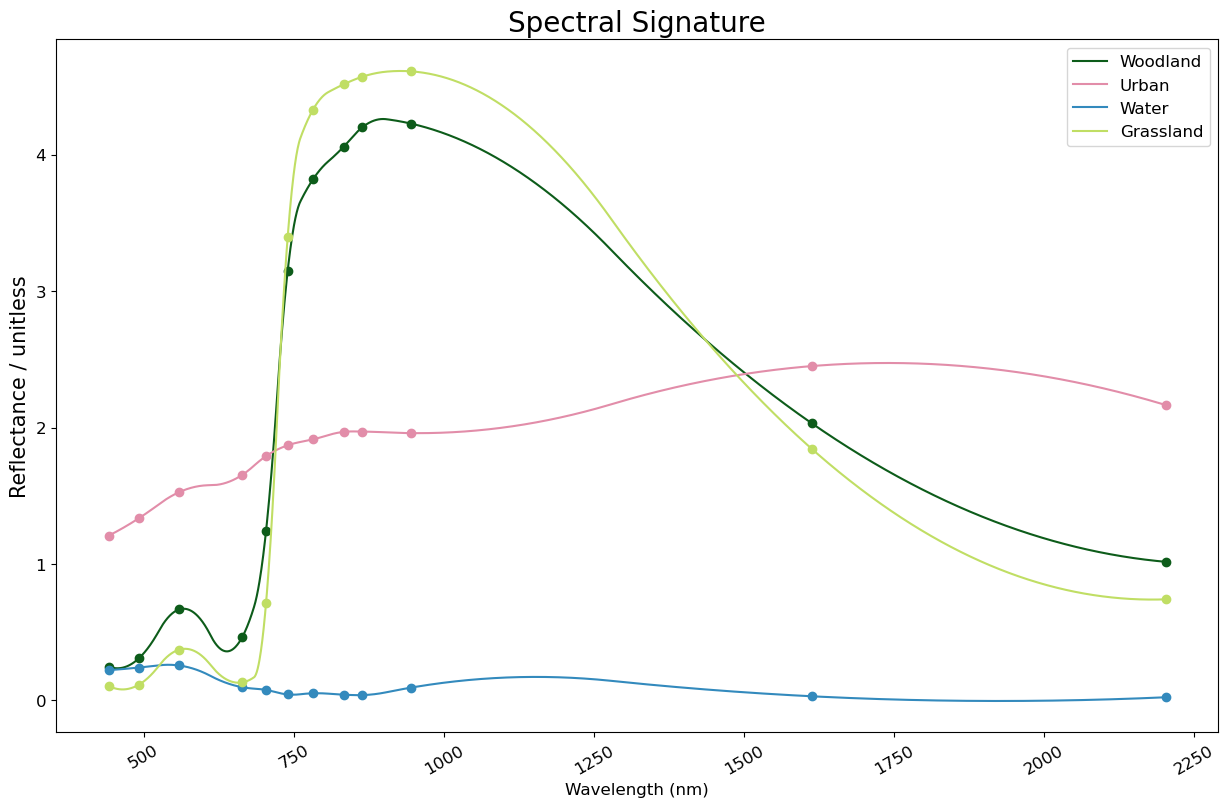

In [12]:
# Create a figure and axis with specified size
fig_stat, ax_stat = plt.subplots(1, 1, figsize=(15, 9))

# Extract spectral values and wavelength by landcover name
wavelength = lcs_df["Wavelength"]
x = wavelength

# Define landcover types, colors, and labels
# Dissolved DataFrame columns are alphabetical: Grassland, Urban, Water, Woodland
# but "Grassland" is actually Woodland, and "Woodland" is actually Grassland
landcover_types = ["Grassland", "Urban", "Water", "Woodland"]
colors = ["#0d5c1a", "#e28da9", "#338abd", "#c0de64"]
labels = ["Woodland", "Urban", "Water", "Grassland"]

# Interpolate and plot each spectral value
for lc_name, color, label in zip(landcover_types, colors, labels):
    if lc_name not in lcs_df.columns:
        continue
    y = lcs_df[lc_name]
    fun = interp1d(x=x, y=y, kind=2)
    x2 = np.linspace(start=442, stop=2202, num=2300)
    y2 = fun(x2)
    ax_stat.plot(x2, y2, label=label, color=color)
    ax_stat.plot(x, y, ls="", marker="o", color=color)

# Set tick parameters
ax_stat.tick_params(axis="x", labelrotation=30, labelsize=12)
ax_stat.tick_params(axis="y", labelsize=12)

# Set labels and title
ax_stat.set_xlabel("Wavelength (nm)", size=12)
ax_stat.set_ylabel("Reflectance / unitless", size=15)
ax_stat.set_title("Spectral Signature", fontsize=20)

# Set legend
ax_stat.legend(loc="upper right", prop={"size": 12})

# Optimize visibility of x-tick labels
for label in ax_stat.get_xticklabels()[0::13]:
    label.set_visible(True)

# Display the plot
plt.show()

Analysing the spectral curves of our land cover types we can see:
- Water generally has low reflectance across the spectrum.
- Both Woodland and Grassland have peaks in their reflectance in the Red Edge and NIR parts of the spectrum. The grassland peak is higher due to the brighter response of grassland compared to darker forest pixels.
- Urban pixels are generally fairly bright across the spectrum. Notably they produce the highest SWIR reflectances. 

## 2. How to create a Histogram & Box Plot of a certain band's values for a field of interest

Histograms and Box Plots are also useful for analysis of the distribution of pixel values in a field of interest. In this example, we are using Processing API to calculate the NDVI. We then plot the distribution of NDVI values in a histogram and a simple box plot.

### Creating a field of interest

Firstly, we will define some fields of interest in France for the first few examples. Our fields of interest and the time period we are using coincides with the temporal and spatial extent of the [PlanetScope](https://collections.sentinel-hub.com/planetscope/sandbox-data.html) dataset within the Planet Sandbox Data Collection. We will use the [Sentinel-2 L2A](https://docs.sentinel-hub.com/api/latest/data/sentinel-2-l2a/) data collection in the first examples though.

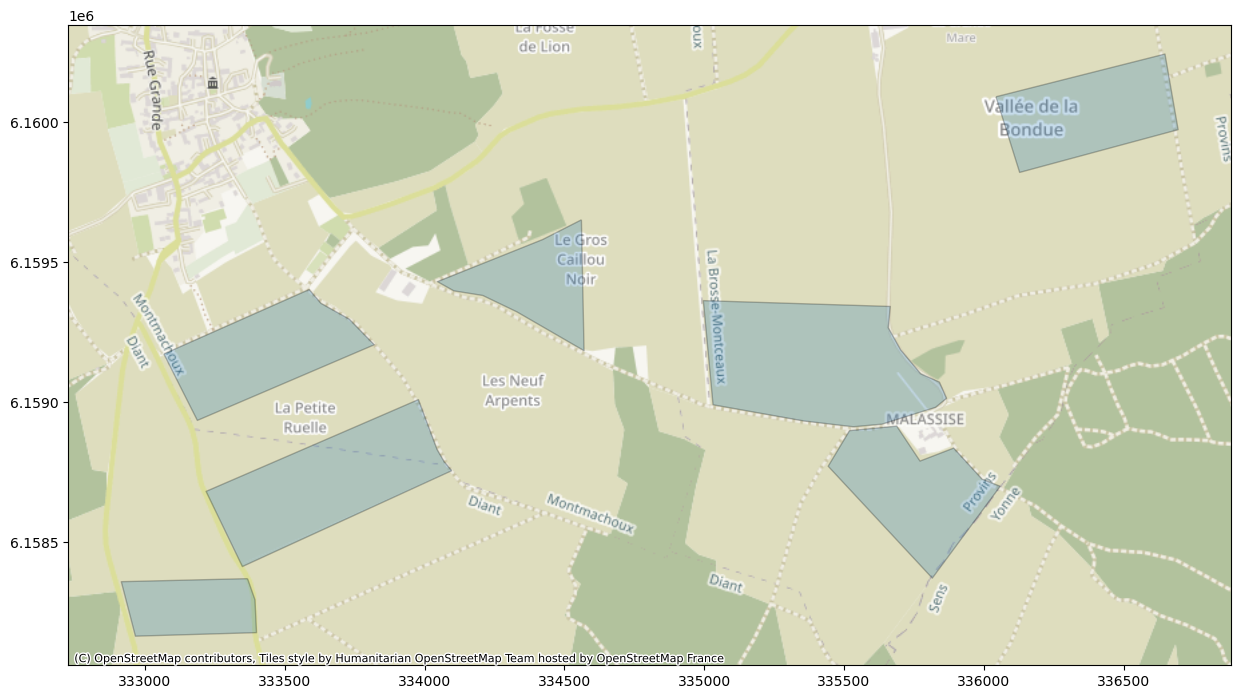

In [13]:
fields_gdf = gpd.read_file("../../data/france_fields.geojson")
fields_gdf["area"] = fields_gdf.geometry.area

fields_gdf_wm = fields_gdf.to_crs(epsg=3857)

# Explore the GeoDataFrame, visualizing the 'area' column with a specified colormap
ax = fields_gdf_wm.plot(alpha=0.25, edgecolor="k", figsize=(15, 15))
cx.add_basemap(ax)

### The Evalscript

In [14]:
evalscript = """
//VERSION=3

function evaluatePixel(samples) {
    if (samples.dataMask == 0){
        return [NaN]
    }
    let val = index(samples.B08, samples.B04);
    return [val];
}

function setup() {
  return {
    input: [{
      bands: [
        "B04",
        "B08",
        "dataMask"
      ]
    }],
    output: {
      bands: 1,
      sampleType: "FLOAT32"
    }
  }
}
"""

### The Request Body

In [15]:
fields_gdf = fields_gdf.to_crs(epsg=3857)

geometry = Geometry(geometry=fields_gdf.geometry.iloc[0], crs=CRS.POP_WEB)
request = SentinelHubRequest(
    evalscript=evalscript,
    input_data=[
        SentinelHubRequest.input_data(
            data_collection=DataCollection.SENTINEL2_L2A.define_from(
                "s2l2a", service_url=config.sh_base_url
            ),
            time_interval=("2024-09-03", "2024-10-03"),
        ),
    ],
    responses=[
        SentinelHubRequest.output_response("default", MimeType.TIFF),
    ],
    geometry=geometry,
    resolution=(10, 10),
    config=config,
)

response = request.get_data()

### Manipulation and Visualisation of our Output

Firstly, let's convert our response into a numpy array.

In [16]:
# converting list to array
arr = np.array(response)

type(arr)

numpy.ndarray

We can then simply flatten the array and plot the distribution of values using Matplotlib. You change the number of bins (columns) in the histogram if you like in the following example.

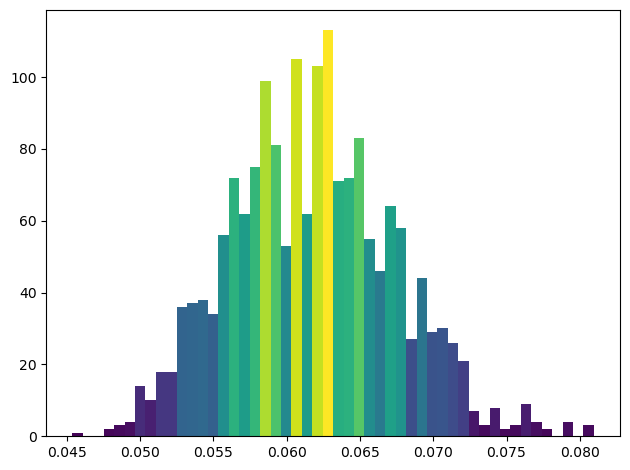

In [17]:
# Flatten the array
dist1 = arr.flatten()

# Create a figure and axis with tight layout
fig, axs = plt.subplots(1, 1, tight_layout=True)

# N is the count in each bin, bins is the lower-limit of the bin
N, bins, patches = axs.hist(dist1, bins=50)

# We'll color code by height, but you could use any scalar
fracs = N / N.max()

# we need to normalize the data to 0..1 for the full range of the colormap
norm = mcolors.Normalize(fracs.min(), fracs.max())

# Now, we'll loop through our objects and set the color of each accordingly
for thisfrac, thispatch in zip(fracs, patches):
    color = plt.cm.viridis(norm(thisfrac))
    thispatch.set_facecolor(color)

With the same data, we can also very easily create a box plot with the following:

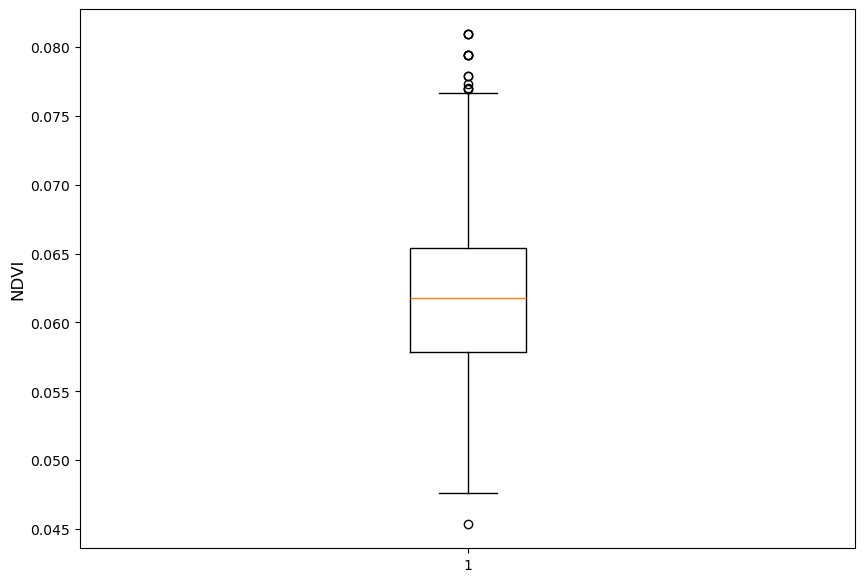

In [18]:
# Filter out NaN values from the numpy array
filtered_data = dist1[~np.isnan(dist1)]

# Create a figure with specified size
fig = plt.figure(figsize=(10, 7))

# Create a boxplot of the filtered data
plt.boxplot(filtered_data)

# Set labels and title

plt.ylabel("NDVI", size=12)

# Show the plot
plt.show()

## 3. Plotting and styling multiple box plots to compare different land cover types

Let's take this a step further and compare the four land cover types from our previous example in and around Geneva, Switzerland. 

### The Evalscript

In [19]:
evalscript = """
//VERSION=3

function evaluatePixel(samples) {
    if (samples.dataMask == 0){
        return [NaN]
    }
    let val = index(samples.B08, samples.B04);
    return [val];
}

function setup() {
  return {
    input: [{
      bands: [
        "B04",
        "B08",
        "dataMask"
      ]
    }],
    output: {
      bands: 1,
      sampleType: "FLOAT32"
    }
  }
}
"""

### The Request Body

In [20]:
lcs_requests = []

for geo_shape in lcs_gdf.geometry.values:
    request = SentinelHubRequest(
        evalscript=evalscript,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=DataCollection.SENTINEL2_L2A.define_from(
                    "s2l2a", service_url=config.sh_base_url
                ),
                time_interval=("2025-05-30", "2025-05-31"),
                other_args={"dataFilter": {"mosaickingOrder": "leastCC"}},
            ),
        ],
        responses=[
            SentinelHubRequest.output_response("default", MimeType.TIFF),
        ],
        geometry=Geometry(geo_shape, crs=CRS(lcs_gdf.crs)),
        resolution=(0.0002, 0.0002),
        config=config,
    )
    lcs_requests.append(request)

In [21]:
%%time

download_requests = [lcs_request.download_list[0] for lcs_request in lcs_requests]

client = SentinelHubDownloadClient(config=config)

lcs_stats = client.download(download_requests)

len(lcs_stats)

CPU times: user 66.3 ms, sys: 19.5 ms, total: 85.7 ms
Wall time: 554 ms


4

### Manipulation and Visualisation of our Output

In this cell we convert all four request outputs into numpy arrays, flatten the arrays and filter out NaN values. We can then plot them as box plots on the same plot. To make best use of the space, we flip them so the band distribution is on the x axis rather than the y axis in the first example.

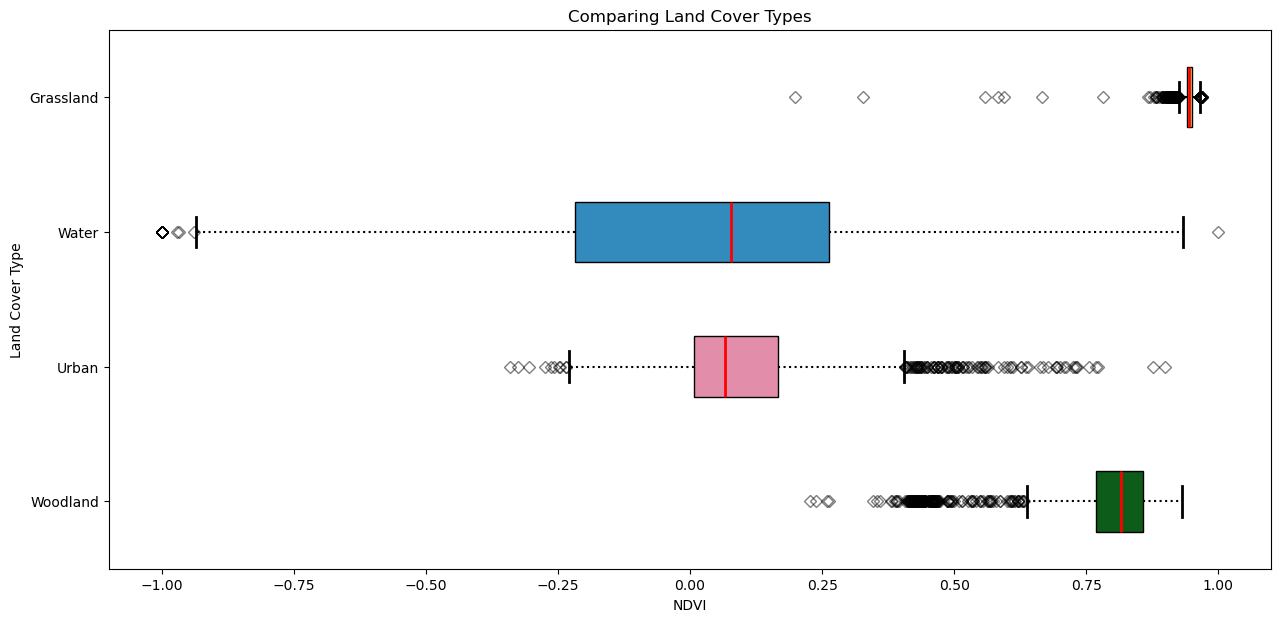

In [22]:
# Convert list to array and flatten, then filter out NaN values
arrays = [np.array(lcs_stats[i], dtype=float).flatten() for i in range(4)]
filtered_data = [arr[~np.isnan(arr)] for arr in arrays]

# Creating dataset
data = filtered_data

# Create a figure with specified size
fig = plt.figure(figsize=(15, 7))
ax = fig.add_subplot(111)

# Create boxplot
bp = ax.boxplot(data, patch_artist=True, vert=False)

# Define colors for the boxplot (CORINE-inspired, matching spectral signature plot)
# lcs_gdf order is alphabetical: Grassland (actually Woodland), Urban, Water, Woodland (actually Grassland)
colors = ["#0d5c1a", "#e28da9", "#338abd", "#c0de64"]

# Set face color for each box
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

# Change color and linewidth of whiskers
for whisker in bp["whiskers"]:
    whisker.set(color="#000000", linewidth=1.5, linestyle=":")

# Change color and linewidth of caps
for cap in bp["caps"]:
    cap.set(color="#000000", linewidth=2)

# Change color and linewidth of medians
for median in bp["medians"]:
    median.set(color="red", linewidth=2)

# Change style of fliers
for flier in bp["fliers"]:
    flier.set(marker="D", color="#000000", alpha=0.5)

# Set y-axis labels (corrected: "Grassland" and "Woodland" are swapped in the dissolved GeoDataFrame)
ax.set_yticklabels(["Woodland", "Urban", "Water", "Grassland"])

# Add title
plt.title("Comparing Land Cover Types")
plt.xlabel("NDVI")
plt.ylabel("Land Cover Type")

# Remove top and right axes ticks
ax.get_xaxis().tick_bottom()
ax.get_yaxis().tick_left()

# Show plot
plt.show()

## 4. Creating a scatter plot comparing two spectral bands

Scatter plots are also useful tools when you are classifying certain land cover types. You can compare the distribution of pixel values of different land cover types with a band/index in each of the x and y axes. In this example, we use Processing API to download 4 land cover types from in and around Geneva. We then manipulate the data to then plot the Red and NIR bands to analyse the distribution of pixel values between the different land cover types.

### The Evalscript

In [23]:
evalscript = """
//VERSION=3

function evaluatePixel(samples) {
    if (samples.dataMask == 0){
        return [NaN, NaN]
    }
    return [samples.B04, samples.B08];
}

function setup() {
  return {
    input: [{
      bands: [
        "B04",
        "B08",
        "dataMask"
      ]
    }],
    output: {
      bands: 2,
      sampleType: "FLOAT32"
    }
  }
}
"""

### The Request Body

In [24]:
lcs_gdf = landcover_samples.dissolve(by="landcover").reset_index()

lcs_requests = []

for geo_shape in lcs_gdf.geometry.values:
    request = SentinelHubRequest(
        data_folder="test_dir",
        evalscript=evalscript,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=DataCollection.SENTINEL2_L2A.define_from(
                    "s2l2a", service_url=config.sh_base_url
                ),
                time_interval=("2025-05-30", "2025-05-31"),
                other_args={"dataFilter": {"mosaickingOrder": "leastCC"}},
            ),
        ],
        responses=[
            SentinelHubRequest.output_response("default", MimeType.TIFF),
        ],
        geometry=Geometry(geo_shape, crs=CRS(lcs_gdf.crs)),
        resolution=(0.0002, 0.0002),
        config=config,
    )
    lcs_requests.append(request)

In [25]:
%%time

download_requests = [lcs_request.download_list[0] for lcs_request in lcs_requests]

client = SentinelHubDownloadClient(config=config).download(
    download_requests, max_threads=5
)

lcs_stats = download_requests

len(lcs_stats)

CPU times: user 7.97 ms, sys: 5.08 ms, total: 13 ms
Wall time: 8.04 ms


4

In [26]:
# List comprehension to find all .tiff files in the specified data folder
files = [
    os.path.join(folder, filename)
    for folder, _, filenames in os.walk(download_requests[0].data_folder)
    for filename in filenames
    if filename.endswith(".tiff")
]

# Display the list of files
files

['test_dir/5c40cf21eb7077ae38b393348d04036a/response.tiff',
 'test_dir/40f1ec20c4a1a15b02b61ee986db3e41/response.tiff',
 'test_dir/3d1a72cb5d032191add76e0c9ed29e26/response.tiff',
 'test_dir/dd2083e4969198e436ef03385c87d3ba/response.tiff',
 'test_dir/a2cfbe2333c61c0fb93d2217024fe631/response.tiff',
 'test_dir/4b8f40e9a914ad59a5719339bb8667b8/response.tiff',
 'test_dir/54efe915fa59413dccb197a80e8f7608/response.tiff',
 'test_dir/272517c238813c5c3af415bc6ff1d2f8/response.tiff',
 'test_dir/a6197822a73163e2f41887236a45cfba/response.tiff',
 'test_dir/d2eafbd0e66ecab4cb057ddc333f6904/response.tiff',
 'test_dir/71d1b794d0dbd8d2a5501522677aa9ba/response.tiff',
 'test_dir/4ce9acb3a24c0935f051e14edd8d5854/response.tiff']

### Manipulation and Visualisation of our Output

Firstly, we open the the saved images using rasterio and then read each band indivdually. We can very quickly plot the pixel values onto a scatter plot. It looks like the majority of pixels for this land cover type are very tightly clustered around low Red and NIR values.

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


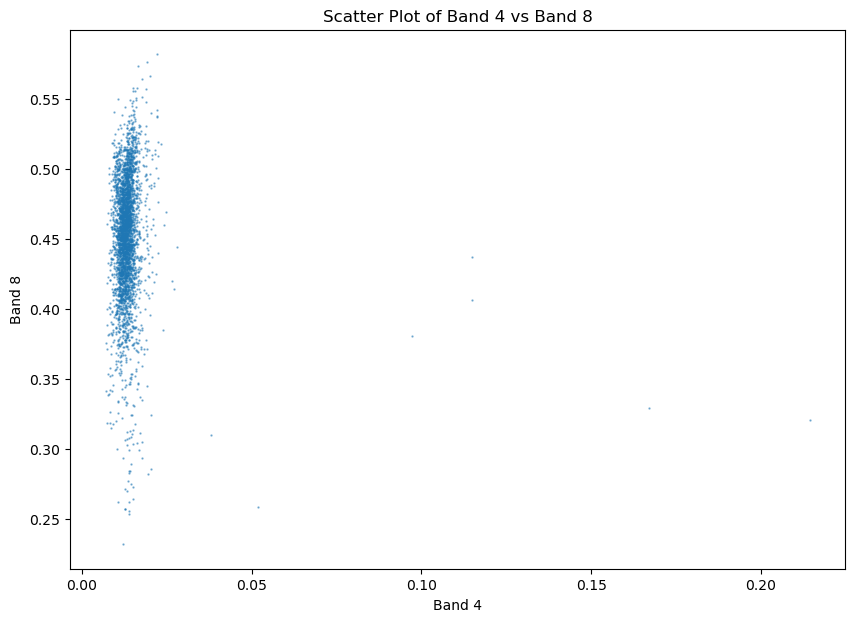

In [27]:
# Open the .tiff files using rasterio
combined_data = [rasterio.open(file) for file in files[:4]]

# Read the first and second bands from the second file
B4 = combined_data[1].read(1)
B8 = combined_data[1].read(2)

# Create a scatter plot of the bands
plt.figure(figsize=(10, 7))
plt.scatter(B4, B8, s=0.5, alpha=0.5)
plt.xlabel("Band 4")
plt.ylabel("Band 8")
plt.title("Scatter Plot of Band 4 vs Band 8")
plt.show()

Let's go further and plot the scatter plots for all four fields of interest. As we already know the land cover types we can also label and style the plot appropriately. The result shows that the four fields of interest have distinct pixel value distributions when comparing the Red and NIR bands. 

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


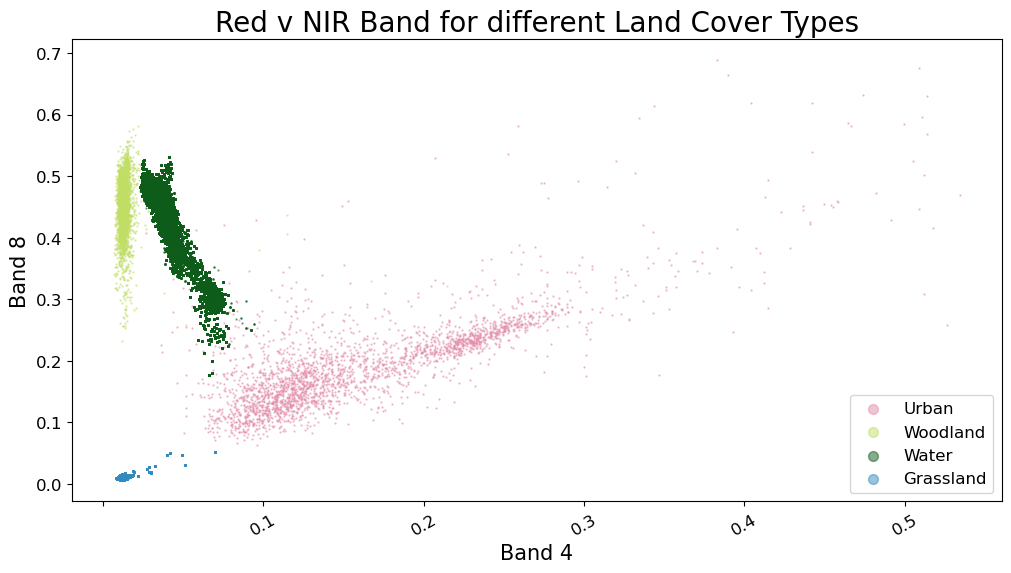

In [28]:
# Create a figure and axis with specified size
fig_stat, ax_stat = plt.subplots(1, 1, figsize=(12, 6))

# Define labels and colors for each dataset
# lcs_gdf order is alphabetical: Grassland (actually Woodland), Urban, Water, Woodland (actually Grassland)
labels = [
    "Urban",
    "Woodland",
    "Water",
    "Grassland",
]
colors = ["#e28da9", "#c0de64", "#0d5c1a", "#338abd"]

# Read the bands and plot the scatter plots, filtering out outliers
for i, (label, color) in enumerate(zip(labels, colors)):
    arr_B4 = combined_data[i].read(1).flatten()
    arr_B8 = combined_data[i].read(2).flatten()
    # Keep only valid reflectance values (0–1 range)
    mask = (
        (arr_B4 >= 0)
        & (arr_B4 <= 1)
        & (arr_B8 >= 0)
        & (arr_B8 <= 1)
        & ~np.isnan(arr_B4)
        & ~np.isnan(arr_B8)
    )
    ax_stat.scatter(
        arr_B4[mask], arr_B8[mask], s=0.5, alpha=0.5, label=label, color=color
    )

# Set tick parameters
ax_stat.tick_params(axis="x", labelrotation=30, labelsize=12)
ax_stat.tick_params(axis="y", labelsize=12)

# Set labels and title
ax_stat.set_xlabel("Band 4", size=15)
ax_stat.set_ylabel("Band 8", size=15)
ax_stat.set_title("Red v NIR Band for different Land Cover Types", fontsize=20)

# Set legend
ax_stat.legend(loc="lower right", prop={"size": 12}, markerscale=10.0)

# Optimize visibility of x-tick labels
for label in ax_stat.get_xticklabels()[1::20]:
    label.set_visible(False)

# Display the plot
plt.show()

## 5. Creating Choropleth maps based on your Statistical API inputs and outputs in Geopandas

In this final example, we will run Statistical API on several fields and extract the mean NDVI for the fields of interest. We will then populate a geopandas dataframe with the geojson geometries and mean NDVI statistics, before creating a simple Choropleth map using GeoPandas.

### Creating the fields of interest

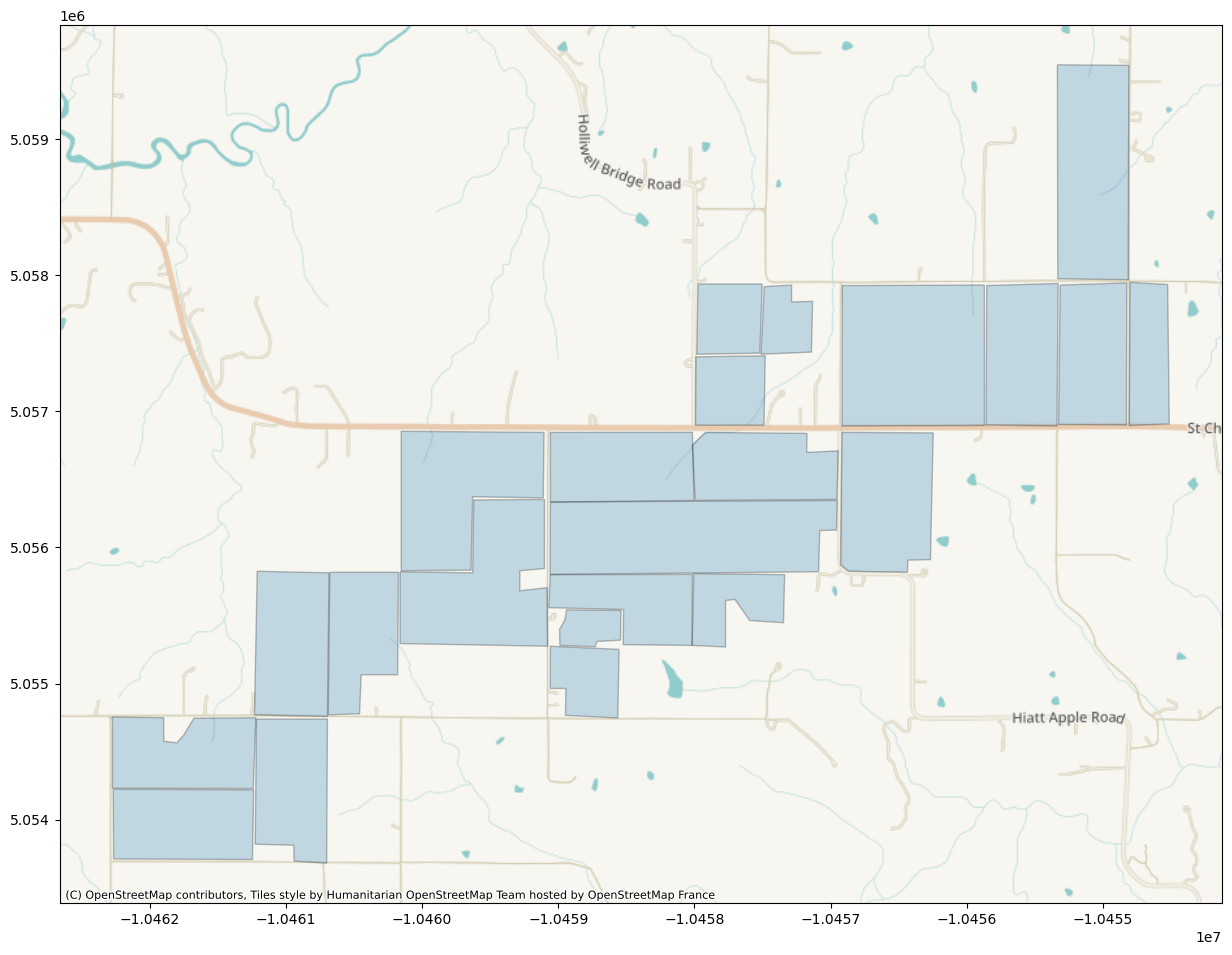

In [29]:
# Read the Nebraska fields into a GeoDataFrame
fields_gdf = gpd.read_file("../../data/north_america_fields.geojson")

# Calculate the area for each geometry and add it as a new column
fields_gdf["area"] = fields_gdf.geometry.area

fields_gdf_wm = fields_gdf.to_crs(epsg=3857)

# Explore the GeoDataFrame, visualizing the 'area' column with a specified colormap
ax = fields_gdf_wm.plot(alpha=0.25, edgecolor="k", figsize=(15, 15))
cx.add_basemap(ax)

### The Evalscript

In [30]:
evalscript = """
//VERSION=3
function setup() {
  return {
    input: [{
      bands: [
        "B04",
        "B08",
        "dataMask"
      ]
    }],
    output: [
      {
        id: "ndvi",
        bands: 1
      },
      {
        id: "dataMask",
        bands: 1
      }]
  };
}

function evaluatePixel(samples) {
    let index = (samples.B08 - samples.B04) / (samples.B08+ samples.B04);
    return {
        ndvi: [index],
        dataMask: [samples.dataMask],
    };
}
"""

### The Request Body

In [31]:
aggregation = SentinelHubStatistical.aggregation(
    evalscript=evalscript,
    time_interval=("2022-07-15T00:00:00Z", "2022-07-20T23:59:59Z"),
    aggregation_interval="P5D",
    resolution=(0.0001, 0.0001),
)

ndvi_requests = []

for geo_shape in fields_gdf.geometry.values:
    request = SentinelHubStatistical(
        aggregation=aggregation,
        input_data=[
            SentinelHubStatistical.input_data(
                DataCollection.SENTINEL2_L2A.define_from(
                    "s2l2a", service_url=config.sh_base_url
                ),
            )
        ],
        geometry=Geometry(geo_shape, crs=CRS(fields_gdf.crs)),
        config=config,
    )
    ndvi_requests.append(request)

In [32]:
%%time

download_requests = [ndvi_request.download_list[0] for ndvi_request in ndvi_requests]

client = SentinelHubStatisticalDownloadClient(config=config)

ndvi_stats = client.download(download_requests)

len(ndvi_stats)

CPU times: user 317 ms, sys: 37.9 ms, total: 354 ms
Wall time: 1.54 s


23

### Manipulation and Visualisation of our Output

In [33]:
# Convert the statistics to DataFrames and assign the 'id' column
ndvi_dfs = [
    stats_to_df(polygon_stats).assign(id=id)
    for polygon_stats, id in zip(ndvi_stats, fields_gdf["id"].values)
]

# Concatenate all DataFrames into a single DataFrame
ndvi_df = pd.concat(ndvi_dfs)

# Display the resulting DataFrame
ndvi_df

,interval_from,interval_to,ndvi_B0_min,ndvi_B0_max,ndvi_B0_mean,ndvi_B0_stDev,ndvi_B0_sampleCount,ndvi_B0_noDataCount,id
0,2022-07-15,2022-07-20,0.169666,0.917975,0.871321,0.076670,7081,1971,1
0,2022-07-15,2022-07-20,0.275174,0.886587,0.772877,0.040235,3325,2,2
0,2022-07-15,2022-07-20,0.539717,0.912925,0.875084,0.035963,6993,301,3
0,2022-07-15,2022-07-20,0.306220,0.873349,0.740673,0.078413,4209,134,4
0,2022-07-15,2022-07-20,0.273075,0.928903,0.887432,0.071828,3528,35,5
0,2022-07-15,2022-07-20,0.526709,0.902356,0.797001,0.056738,6486,1694,6
0,2022-07-15,2022-07-20,0.571810,0.908697,0.793643,0.054638,3255,0,7
0,2022-07-15,2022-07-20,0.416477,0.912436,0.808322,0.051187,3408,223,8
0,2022-07-15,2022-07-20,0.488170,0.847131,0.703280,0.060892,3266,492,9
0,2022-07-15,2022-07-20,0.378391,0.767840,0.666468,0.051343,1656,168,10


In the below cell, we convert the mean NDVI column into a list and then insert it in the pandas geodataframe we created earlier. We can then visualise mean NDVI using this column and an appropriate color map.

Text(132.34722222222223, 0.5, 'Northing')

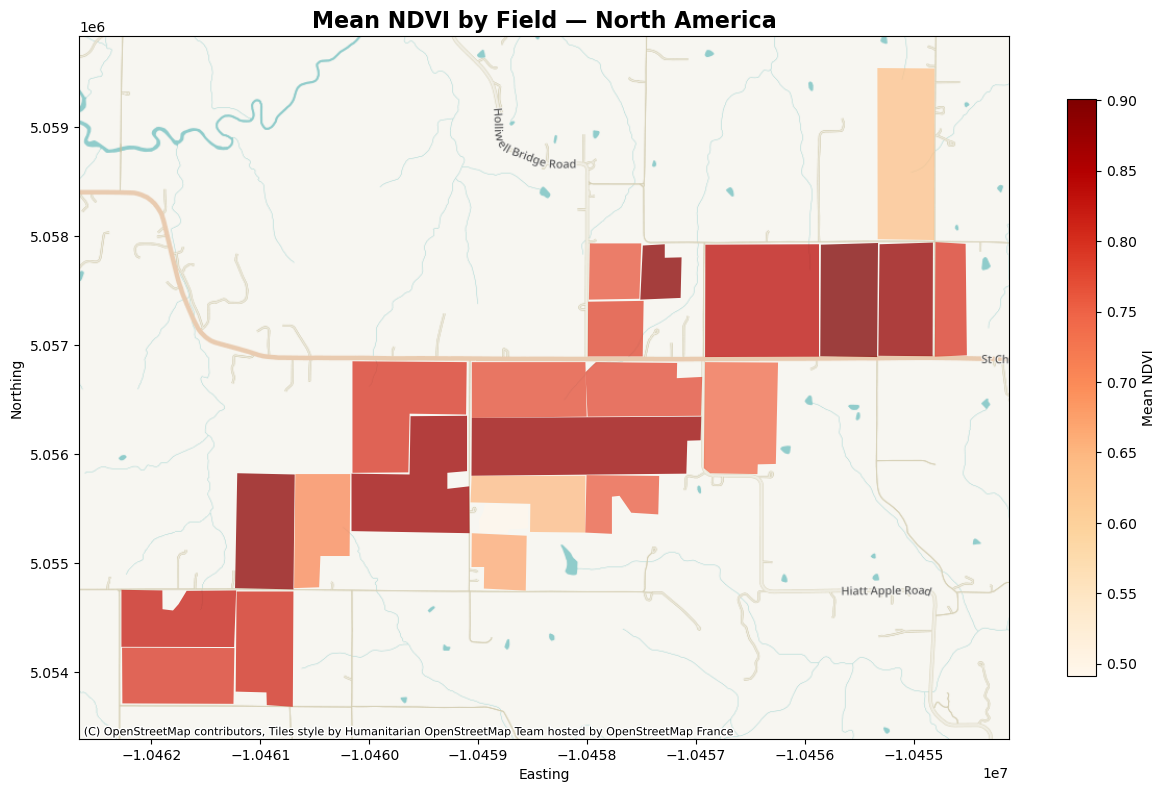

In [34]:
# Extract the mean NDVI values from the DataFrame and convert to a list
mean_ndvi = ndvi_df["ndvi_B0_mean"].tolist()

# Insert the mean NDVI values into the GeoDataFrame as a new column
# fields_gdf.insert(1, "mean_ndvi", mean_ndvi)
fields_gdf["mean_ndvi"] = mean_ndvi

# Explore the GeoDataFrame, visualizing the 'mean_ndvi' column with a specified colormap

fields_gdf_wm = fields_gdf.to_crs(epsg=3857)
ax = fields_gdf_wm.plot(
    column="mean_ndvi",
    cmap="OrRd",
    legend=True,
    alpha=0.75,
    figsize=(15, 15),
    legend_kwds={"shrink": 0.5, "label": "Mean NDVI"},
)
cx.add_basemap(ax)

ax.set_title("Mean NDVI by Field — North America", fontsize=16, fontweight="bold")
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")

## 6. CLMS Forest Type Statistics — Comparing EU Countries

So far we have focused on NDVI time series for agricultural fields. The Statistical API works with **any** Sentinel Hub data collection — including Copernicus Land Monitoring Service (CLMS) datasets. In this example we use the **CLMS High Resolution Layer: Forest Type** product, a pan-European raster dataset classifying forest pixels into five types.

Using the Statistical API with a **histogram calculation**, we can count how many pixels belong to each forest type class for **several EU countries** — and compare the results side-by-side in a stacked bar chart. We load country boundaries from the Natural Earth shapefile in the `data/` folder.

### The CLMS Forest Type Collection

The CLMS Forest Type layer is available in Sentinel Hub via its BYOC collection ID:
- **Collection ID:** `35fecfec-8a73-4723-bb08-b775f283a535`
- **Epoch:** 2018 (static layer, request any date in 2018–2019)
- **Resolution:** 10 m
- **Classes:** 0=Unknown, 1=Evergreen needle leaf, 2=Evergreen broad leaf, 3=Deciduous needle leaf, 4=Deciduous broad leaf, 5=Mix of forest types

### The Evalscript

The evalscript simply passes through the `Forest_Type` band value. The magic happens in the `calculations` parameter of the request, where we ask for a histogram that bins pixel counts by class value.

In [35]:
forest_type_evalscript = """
//VERSION=3
function setup() {
  return {
    input: [{ bands: ["Forest_Type", "dataMask"] }],
    output: [
      { id: "data", bands: 1, sampleType: "UINT8" },
      { id: "dataMask", bands: 1 }
    ]
  };
}

function evaluatePixel(samples) {
    return {
        data: [samples.Forest_Type],
        dataMask: [samples.dataMask],
    };
}
"""

### The Request Body

We load country boundaries from the Natural Earth shapefile and select a few EU countries to compare. For each country we use the bounding box to query the Statistical API for a histogram of Forest Type classes.

In [36]:
# Load country boundaries from Natural Earth shapefile
countries_gdf = gpd.read_file(
    "../../data/ne_50m_admin_0_countries/ne_50m_admin_0_countries.shp"
)

# Select EU countries to compare (choose countries covered by CLMS)
selected_countries = [
    "Norway",
    "Latvia",
    "Italy",
    "Austria",
    "Finland",
    "Belgium",
    "Croatia",
    "Serbia",
    "Germany",
    "Netherlands",
    "Poland",
]
eu_countries = countries_gdf[countries_gdf["NAME"].isin(selected_countries)].copy()

# Define histogram bins — one bin per Forest Type class (0 to 6)
calculations = {"default": {"histograms": {"default": {"bins": list(range(7))}}}}

# Loop over countries and make requests
forest_type_responses = {}

for _, row in eu_countries.iterrows():
    country_name = row["NAME"]
    bounds = row.geometry.bounds  # (minx, miny, maxx, maxy)
    country_bbox = BBox(bbox=list(bounds), crs=CRS.WGS84)

    print(f"Requesting Forest Type data for {country_name}...")

    request = SentinelHubStatistical(
        aggregation=SentinelHubStatistical.aggregation(
            evalscript=forest_type_evalscript,
            time_interval=("2019-01-01T00:00:00Z", "2019-01-02T23:59:59Z"),
            aggregation_interval="P1D",
            resolution=(0.05, 0.05),  # coarser resolution for country-scale
        ),
        input_data=[
            SentinelHubStatistical.input_data(
                DataCollection.define_byoc("35fecfec-8a73-4723-bb08-b775f283a535"),
            ),
        ],
        bbox=country_bbox,
        calculations=calculations,
        config=config,
    )

    forest_type_responses[country_name] = request.get_data()

print("Done.")

Requesting Forest Type data for Serbia...
Requesting Forest Type data for Poland...
Requesting Forest Type data for Norway...
Requesting Forest Type data for Netherlands...
Requesting Forest Type data for Latvia...
Requesting Forest Type data for Italy...
Requesting Forest Type data for Germany...
Requesting Forest Type data for Finland...
Requesting Forest Type data for Croatia...
Requesting Forest Type data for Belgium...
Requesting Forest Type data for Austria...
Done.


### Manipulation and Visualisation of our Output

We extract the per-class pixel counts from each country's histogram response, combine them into a single DataFrame, and convert raw counts to percentages for a fair comparison.

In [37]:
# Official Forest Type class labels and colours
forest_type_info = {
    1: ("Evergreen needle leaf", "#666000"),
    2: ("Evergreen broad leaf", "#009900"),
    3: ("Deciduous needle leaf", "#70663e"),
    4: ("Deciduous broad leaf", "#a0dc00"),
    5: ("Mix of forest types", "#929900"),
    0: ("Unforested", "#ffffff"),
}

# Parse histograms for all countries into a single DataFrame
all_rows = []
for country_name, response in forest_type_responses.items():
    hist_bins = response[0]["data"][0]["outputs"]["data"]["bands"]["B0"]["histogram"][
        "bins"
    ]
    for b in hist_bins:
        cls = int(b["lowEdge"])
        info = forest_type_info.get(cls, (f"Class {cls}", "#cccccc"))
        all_rows.append(
            {
                "country": country_name,
                "class": cls,
                "count": b["count"],
                "name": info[0],
                "color": info[1],
            }
        )

ft_df = pd.DataFrame(all_rows)

# Filter out classes with zero counts
ft_df = ft_df[ft_df["count"] > 0]

# Convert counts to percentages per country for fair comparison
ft_df["total"] = ft_df.groupby("country")["count"].transform("sum")
ft_df["pct"] = (ft_df["count"] / ft_df["total"]) * 100

ft_df

,country,class,count,name,color,total,pct
0,Serbia,0,4262,Unforested,#ffffff,6554,65.028990
1,Serbia,1,165,Evergreen needle leaf,#666000,6554,2.517547
4,Serbia,4,2077,Deciduous broad leaf,#a0dc00,6554,31.690571
5,Serbia,5,50,Mix of forest types,#929900,6554,0.762893
6,Poland,0,17108,Unforested,#ffffff,22229,76.962526
7,Poland,1,3930,Evergreen needle leaf,#666000,22229,17.679608
10,Poland,4,852,Deciduous broad leaf,#a0dc00,22229,3.832831
11,Poland,5,339,Mix of forest types,#929900,22229,1.525035
12,Norway,0,52615,Unforested,#ffffff,103379,50.895250
13,Norway,1,44558,Evergreen needle leaf,#666000,103379,43.101597


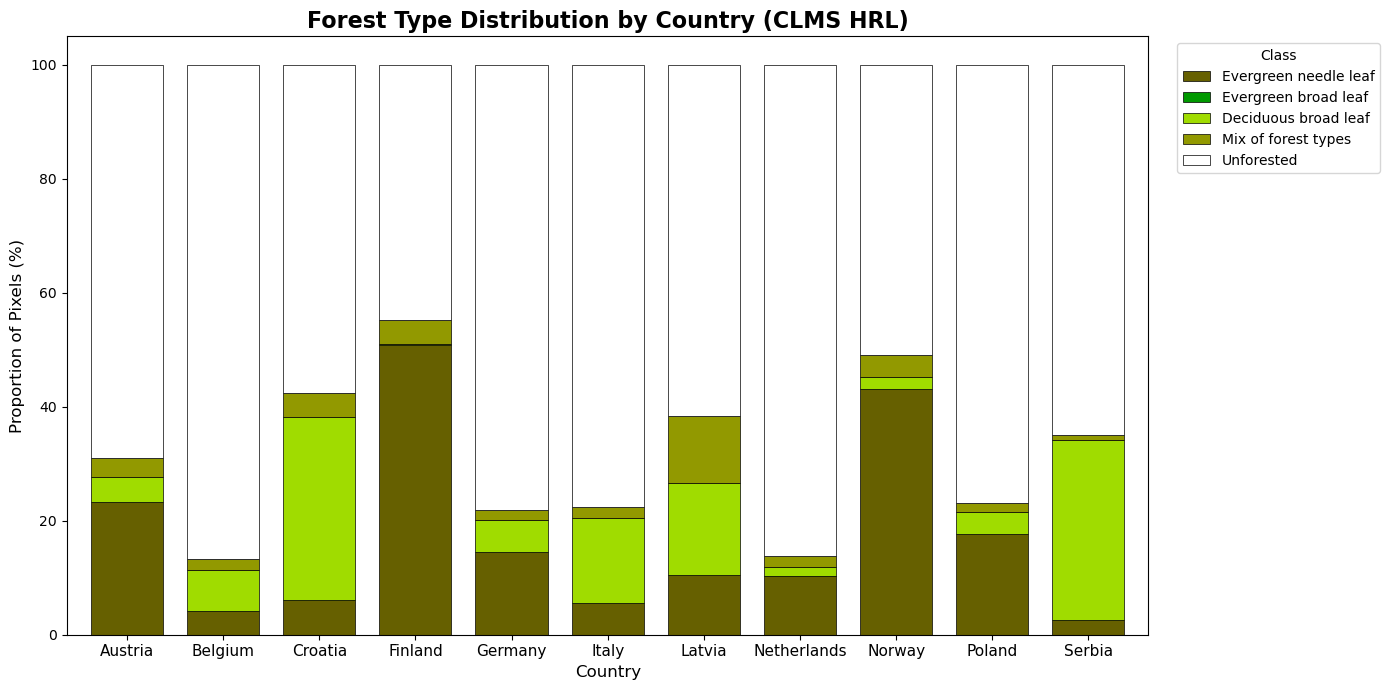

In [38]:
# ── Stacked bar chart: Forest Type distribution by country ────────────────
# Pivot to get countries as rows, forest types as columns
pivot = ft_df.pivot_table(index="country", columns="name", values="pct", fill_value=0)

# Define consistent colours from official palette
ft_colors = {info[0]: info[1] for info in forest_type_info.values()}

# Reorder columns to match class order
col_order = [v[0] for v in forest_type_info.values() if v[0] in pivot.columns]
pivot = pivot[col_order]

fig, ax = plt.subplots(figsize=(14, 7))

pivot.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=[ft_colors[c] for c in pivot.columns],
    edgecolor="black",
    linewidth=0.5,
    width=0.75,
)

ax.set_title(
    "Forest Type Distribution by Country (CLMS HRL)", fontsize=16, fontweight="bold"
)
ax.set_xlabel("Country", fontsize=12)
ax.set_ylabel("Proportion of Pixels (%)", fontsize=12)
ax.set_xticklabels(pivot.index, rotation=0, fontsize=11)
ax.legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)

plt.tight_layout()
plt.show()

## Summary

Congratulations on completing the advanced notebook! You have now learned how to:

- Plot a **spectral signature** for multiple land cover types.
- Create **histograms and box plots** for band value distributions.
- Compare land cover types with **styled box plots** and **scatter plots**.
- Create **choropleth maps** from Statistical API outputs.
- Compare **CLMS Forest Type** statistics across multiple EU countries with a **stacked bar chart**.

These visualisation patterns are reusable with any Statistical API dataset — not just the examples shown here!